# $(SASA) Regular$

$loss = \alpha \times mse(\hat{\theta_i^a}, \hat{\theta_j^a}) + \beta \times (1-mse(\hat{\theta_i^a}, \hat{\theta_k^b})) + \gamma \times mse(\hat{s_{i+2}^a}, y) + \lambda(\hat{\theta_i^a}^2 + \hat{\theta_k^b}^2 + \hat{\theta_j^a}^2)$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [ ]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model, Triplet_Loss
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [ ]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
69,39,3,"(0.05, 1.7)","(0.431, 0.534, -0.163, -0.321)",1,1.0,"(0.441, 0.72, -0.169, -0.417)",1.0,1.0,"(0.456, 0.906, -0.177, -0.514)"
165,20,7,"(0.27, 1.1)","(0.11, 0.788, -0.02, -0.488)",0,1.0,"(0.126, 0.599, -0.03, -0.34)",1.0,1.0,"(0.138, 0.788, -0.037, -0.497)"
92,8,5,"(0.63, 1.5)","(0.035, 0.031, -0.002, -0.021)",0,1.0,"(0.036, -0.158, -0.002, 0.138)",1.0,1.0,"(0.033, 0.031, 0.0, -0.022)"
191,4,9,"(0.11, 0.5)","(0.035, -0.022, 0.013, 0.038)",0,1.0,"(0.035, -0.217, 0.014, 0.337)",1.0,1.0,"(0.031, -0.022, 0.02, 0.047)"
167,22,7,"(0.27, 1.1)","(0.138, 0.788, -0.037, -0.497)",1,1.0,"(0.154, 0.977, -0.047, -0.654)",1.0,1.0,"(0.173, 1.166, -0.06, -0.814)"
...,...,...,...,...,...,...,...,...,...,...
53,23,3,"(0.05, 1.7)","(0.135, 0.899, -0.033, -0.345)",1,1.0,"(0.153, 1.085, -0.04, -0.431)",0.0,1.0,"(0.175, 0.899, -0.049, -0.351)"
81,8,4,"(0.93, 1.7)","(-0.025, -0.771, 0.127, 0.96)",0,1.0,"(-0.04, -0.964, 0.146, 1.201)",0.0,1.0,"(-0.06, -1.156, 0.17, 1.443)"
143,5,6,"(0.97, 0.2)","(0.003, 0.273, -0.026, -2.358)",1,1.0,"(0.008, 0.548, -0.073, -4.423)",0.0,1.0,"(0.019, 0.281, -0.161, -2.577)"
41,11,3,"(0.05, 1.7)","(-0.081, 0.529, 0.05, -0.199)",1,1.0,"(-0.07, 0.714, 0.047, -0.277)",0.0,1.0,"(-0.056, 0.528, 0.041, -0.19)"


In [ ]:
model = Model(transition_criterion_clss=Triplet_Loss)

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000, margin=.5)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_positive,mse_negative,mse_s,regularize,transition,reward
0,0,"[0.11283959448337555, 1.0576897859573364]","[0.13365118205547333, 0.9779279232025146]","[0.06511645019054413, 0.6584089994430542, 0.00...",1.857051,1.749263,2.145152
1,1,"[0.1133466586470604, 1.0625545978546143]","[0.13392822444438934, 0.9817295074462891]","[0.06285054981708527, 0.6519138216972351, 0.00...",1.855977,1.734508,2.137259
2,2,"[0.11386162787675858, 1.0674244165420532]","[0.13421586155891418, 0.9855385422706604]","[0.060649625957012177, 0.6454924941062927, 0.0...",1.854938,1.719957,2.129477
3,3,"[0.1143781840801239, 1.0722655057907104]","[0.13451285660266876, 0.9893295168876648]","[0.05851477012038231, 0.6391427516937256, 0.00...",1.853937,1.705610,2.121814
4,4,"[0.11488869041204453, 1.0771163702011108]","[0.13481254875659943, 0.9931274652481079]","[0.056446921080350876, 0.6328667402267456, 0.0...",1.852977,1.691464,2.114294


In [224]:
data.training_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__
69,39,3,"(0.05, 1.7)","(0.431, 0.534, -0.163, -0.321)",1,1.0,"(0.441, 0.72, -0.169, -0.417)",1.0,1.0,"(0.456, 0.906, -0.177, -0.514)"
165,20,7,"(0.27, 1.1)","(0.11, 0.788, -0.02, -0.488)",0,1.0,"(0.126, 0.599, -0.03, -0.34)",1.0,1.0,"(0.138, 0.788, -0.037, -0.497)"
92,8,5,"(0.63, 1.5)","(0.035, 0.031, -0.002, -0.021)",0,1.0,"(0.036, -0.158, -0.002, 0.138)",1.0,1.0,"(0.033, 0.031, 0.0, -0.022)"
191,4,9,"(0.11, 0.5)","(0.035, -0.022, 0.013, 0.038)",0,1.0,"(0.035, -0.217, 0.014, 0.337)",1.0,1.0,"(0.031, -0.022, 0.02, 0.047)"
167,22,7,"(0.27, 1.1)","(0.138, 0.788, -0.037, -0.497)",1,1.0,"(0.154, 0.977, -0.047, -0.654)",1.0,1.0,"(0.173, 1.166, -0.06, -0.814)"


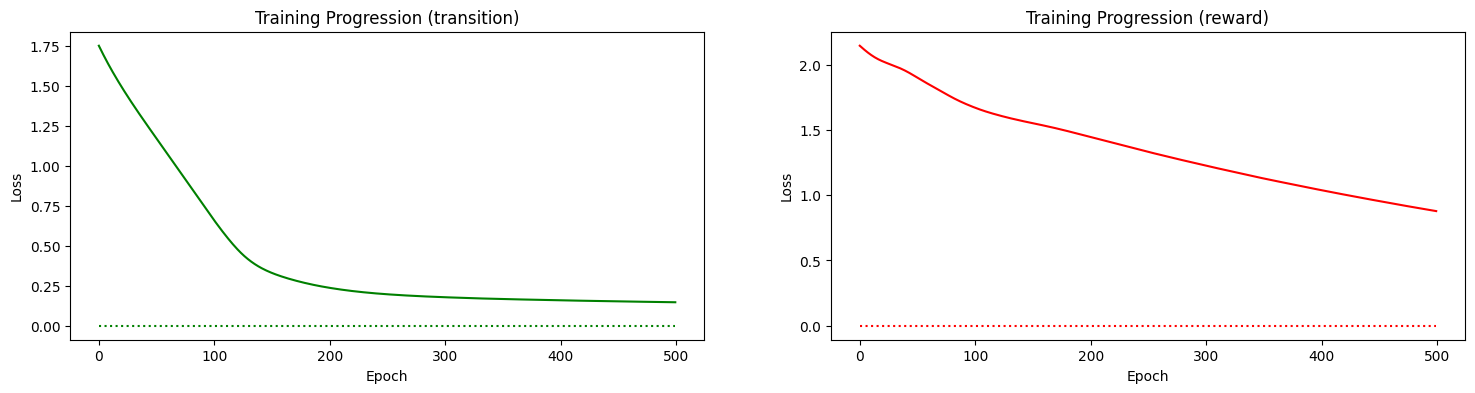

In [225]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

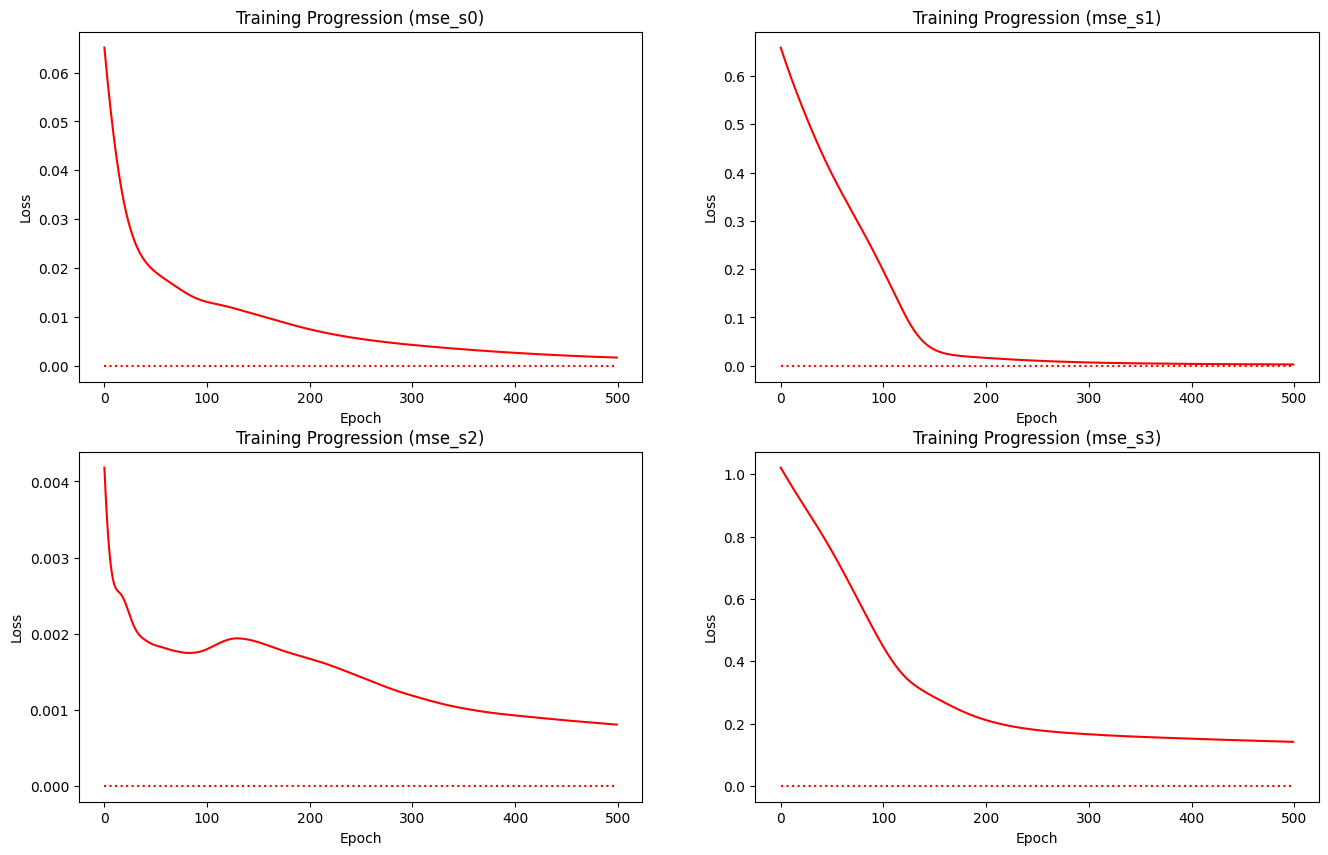

In [226]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(16, 4))

data.plot_training_loss(axs, df['triplet'], 'r')

plt.show()

## Params

In [ ]:
import pandas as pd

training_params = pd.DataFrame(y.numpy(), columns=model.targets_lables)

expansions = {
    'p': ['p0', 'p1']
}
df_trainning = get_data_expanded(data.training_data.loc[(data.training_data.epoch==499)], expansions)

df_trainning_p = pd.DataFrame([], columns=['epoch', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1', 'p0', 'p1'])
for epoch in df_trainning.epoch.unique():
    copy = df_trainning[df_trainning.epoch == epoch].copy()[['epoch', 'p0', 'p1']].reset_index(drop=True)
    copy[['sample', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']] = training_params.copy()[['positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']].reset_index()
    df_trainning_p = pd.concat([df_trainning_p, copy])

df_trainning_p.head()

/tmp/ipykernel_6224/2347339348.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_trainning_p = pd.concat([df_trainning_p, copy])


,epoch,positive_p0,positive_p1,negative_p0,negative_p1,p0,p1,sample
0,0,0.05,1.7,0.63,0.3,0.217277,0.336907,0.0
1,0,0.27,1.1,0.11,0.5,0.192435,0.171322,1.0
2,0,0.63,1.5,0.27,1.1,0.176261,0.261062,2.0
3,0,0.11,0.5,0.57,0.2,0.188142,0.266072,3.0
4,0,0.27,1.1,0.63,1.5,0.261227,0.211184,4.0


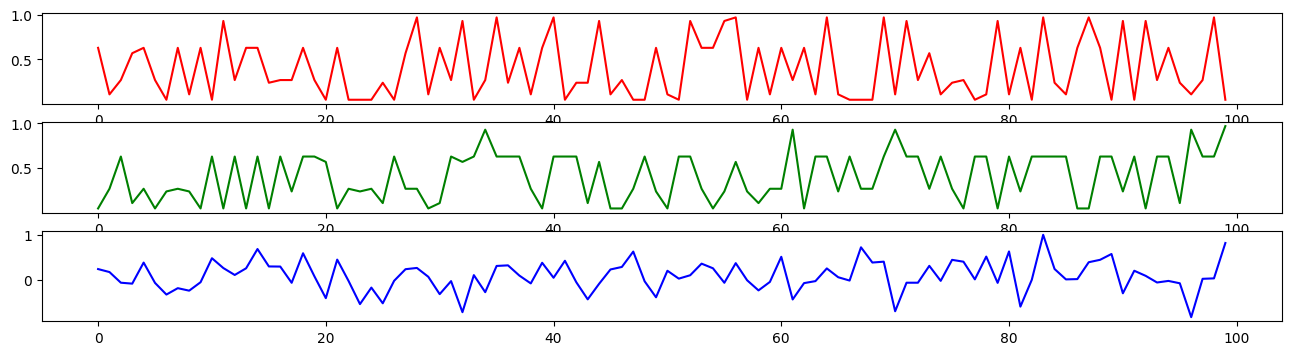

In [229]:
fig, axs = plt.subplots(3, 1, figsize=(16, 4))

axs[0].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['negative_p0'], color='r', label='negative')
axs[1].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['positive_p0'], color='g', label='positve')
axs[2].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['p0'], color='b', label='estimative')

plt.show()

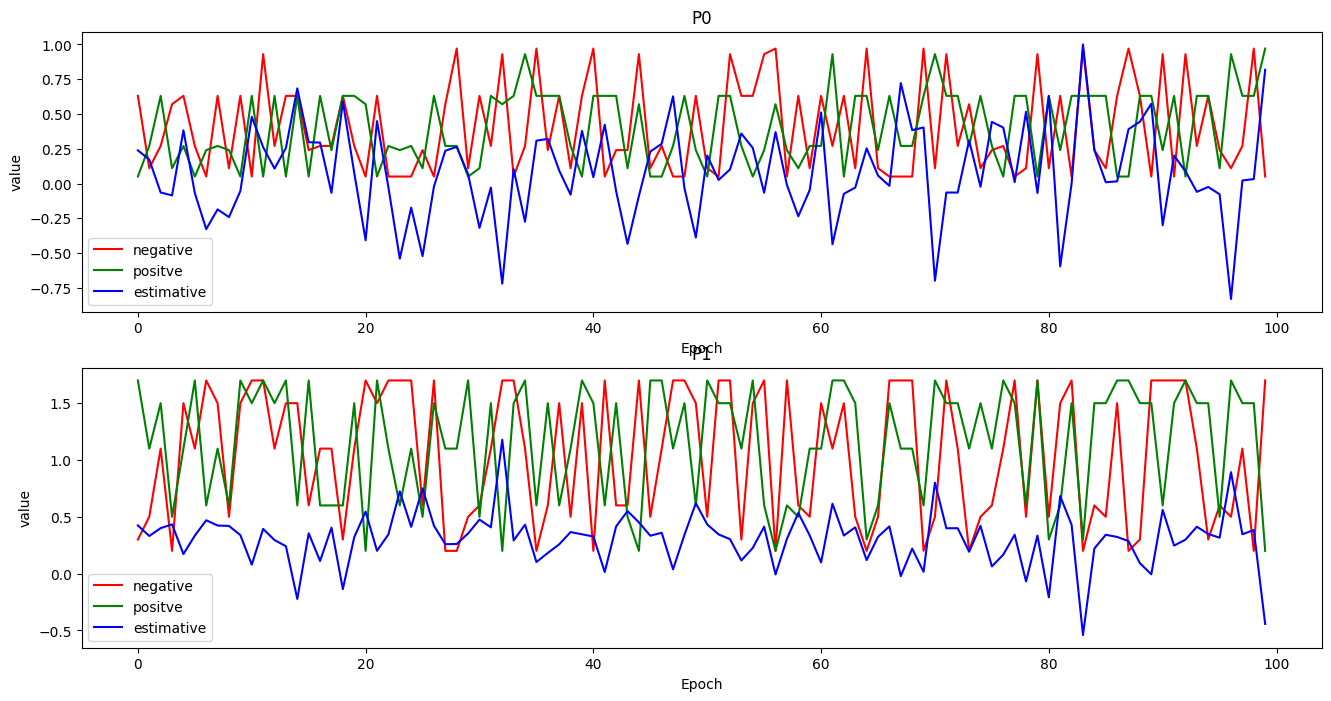

In [230]:
fig, axs = plt.subplots(2,1, figsize=(16, 8))

# df = df_trainning_p.groupby('epoch').mean()
# df = df_trainning_p.groupby('sample').mean()
df = df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]

axs[0].plot(df['negative_p0'], color='r', label='negative')
axs[0].plot(df['positive_p0'], color='g', label='positve')
axs[0].plot(df['p0'], color='b', label='estimative')

axs[0].set_ylabel('value')
axs[0].set_xlabel('Epoch')
axs[0].set_title(f'P0')
axs[0].legend()

axs[1].plot(df['negative_p1'], color='r', label='negative')
axs[1].plot(df['positive_p1'], color='g', label='positve')
axs[1].plot(df['p1'], color='b', label='estimative')

axs[1].set_ylabel('value')
axs[1].set_xlabel('Epoch')
axs[1].set_title(f'P1')
axs[1].legend()

plt.show()

## Best and worst episodes

In [ ]:
data.evaluate_model(model, path='training_data.csv')
results = data.get_evaluation_metrics()
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,...,estimated_s3,p0,p1,estimated_p0,estimated_p1,rse_s0,rse_s1,rse_s2,rse_s3,rse_r
0,0,0,"(0.24, 0.6)","(-0.041, 0.037, 0.015, -0.0)",0,1.0,"(-0.04, -0.157, 0.015, 0.276)",1.0,1.0,"(-0.043, 0.037, 0.02, 0.009)",...,-0.020,0.24,0.6,-0.067,0.404,0.021,0.034,0.021,0.029,1.0
1,1,0,"(0.24, 0.6)","(-0.04, -0.157, 0.015, 0.276)",1,1.0,"(-0.043, 0.037, 0.02, 0.009)",1.0,1.0,"(-0.042, 0.231, 0.02, -0.257)",...,-0.290,0.24,0.6,-0.011,0.305,0.025,0.022,0.012,0.033,0.9
2,2,0,"(0.24, 0.6)","(-0.043, 0.037, 0.02, 0.009)",1,1.0,"(-0.042, 0.231, 0.02, -0.257)",1.0,1.0,"(-0.038, 0.425, 0.015, -0.523)",...,-0.490,0.24,0.6,0.039,0.297,0.037,0.022,0.006,0.033,0.9
3,3,0,"(0.24, 0.6)","(-0.042, 0.231, 0.02, -0.257)",1,1.0,"(-0.038, 0.425, 0.015, -0.523)",0.0,1.0,"(-0.029, 0.23, 0.005, -0.247)",...,-0.236,0.24,0.6,0.161,0.207,0.021,0.024,0.000,0.011,1.0
4,4,0,"(0.24, 0.6)","(-0.038, 0.425, 0.015, -0.523)",0,1.0,"(-0.029, 0.23, 0.005, -0.247)",0.0,1.0,"(-0.025, 0.036, -0.0, 0.026)",...,0.087,0.24,0.6,0.057,0.324,0.015,0.041,0.017,0.061,1.0


In [232]:
rmse = results[['episode', 'rse_s0', 'rse_s1', 'rse_s2', 'rse_s3']].groupby('episode').mean().reset_index()
rmse['rmse'] = rmse.rse_s0 + rmse.rse_s1 + rmse.rse_s2 + rmse.rse_s3
rmse_sorted = rmse.sort_values(by='rmse')
epis = rmse.shape[0]

best_episodes = rmse_sorted.head(3).episode.values
worst_episodes = rmse_sorted.tail(3).episode.values
print(f'{best_episodes=}', f'{worst_episodes=}')

best_episodes=array([0, 9, 5]) worst_episodes=array([1, 2, 6])


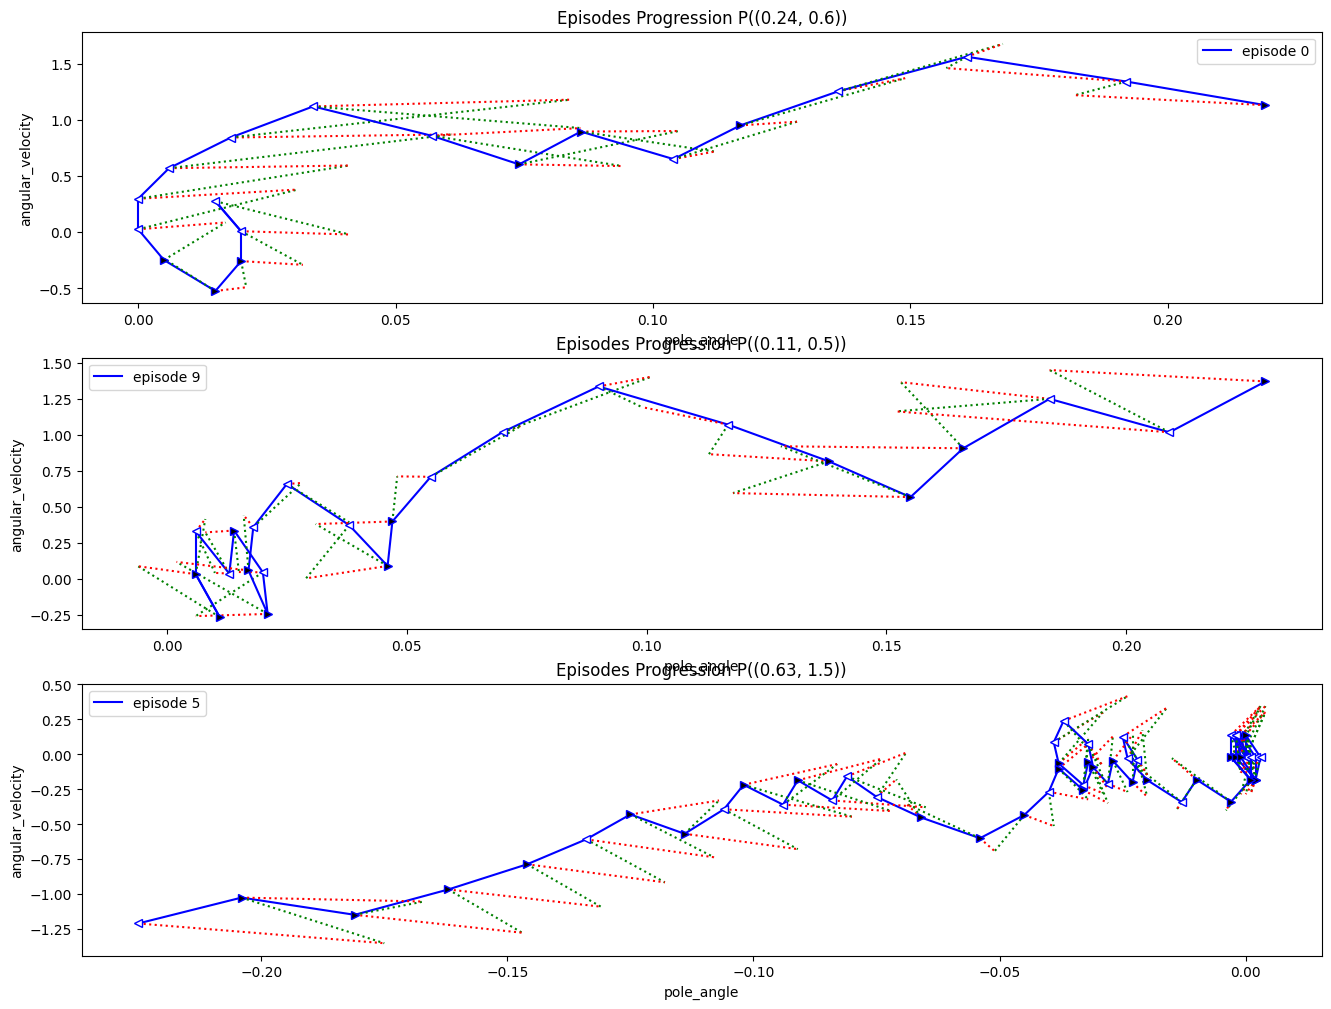

In [233]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(best_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

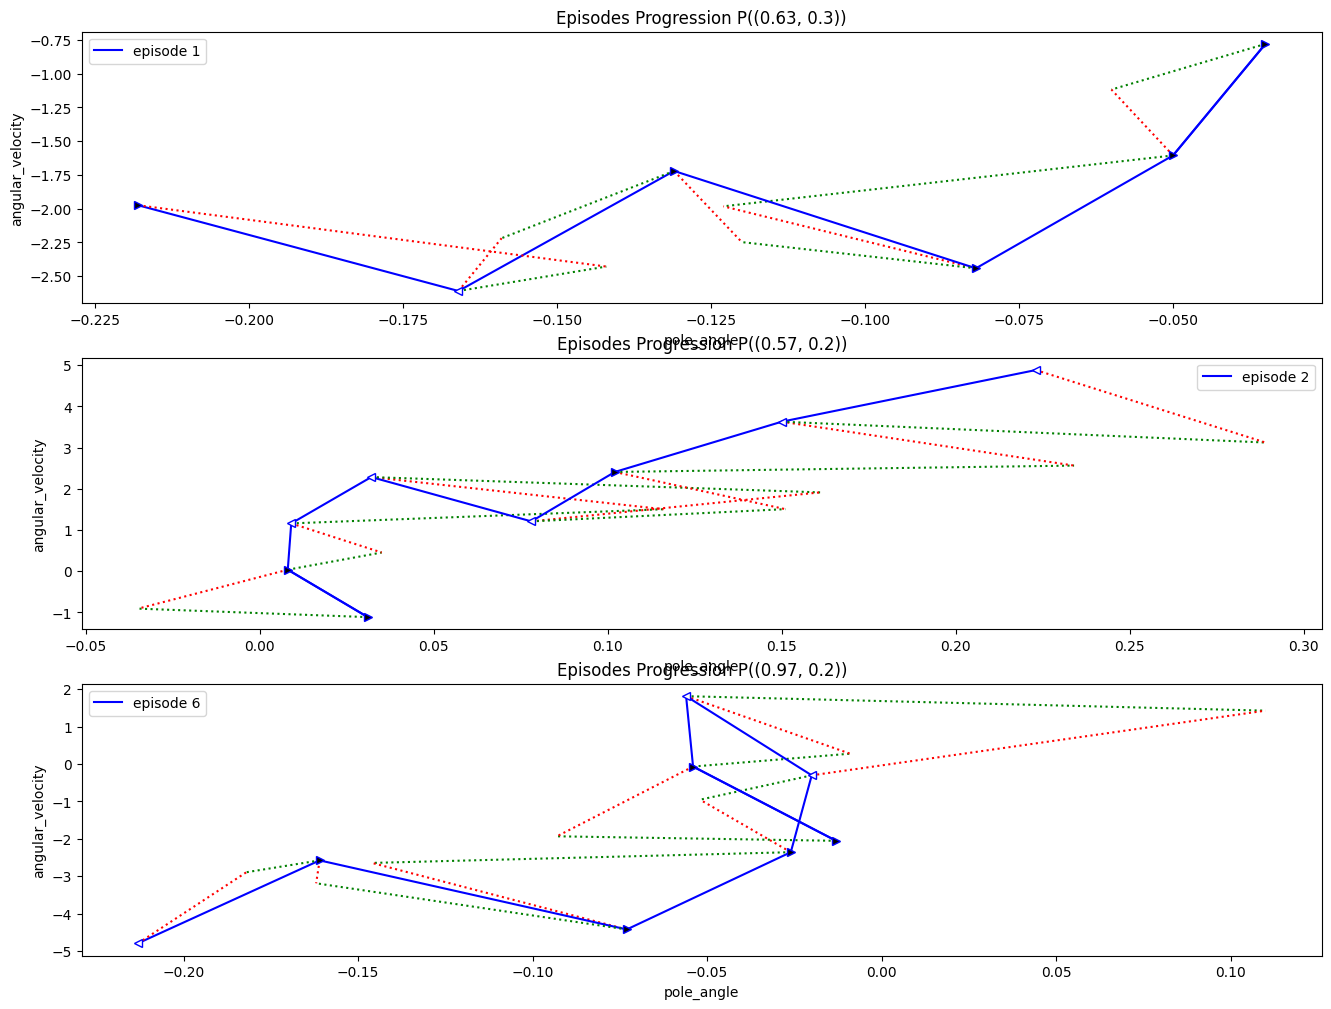

In [234]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(worst_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

## Kmeans

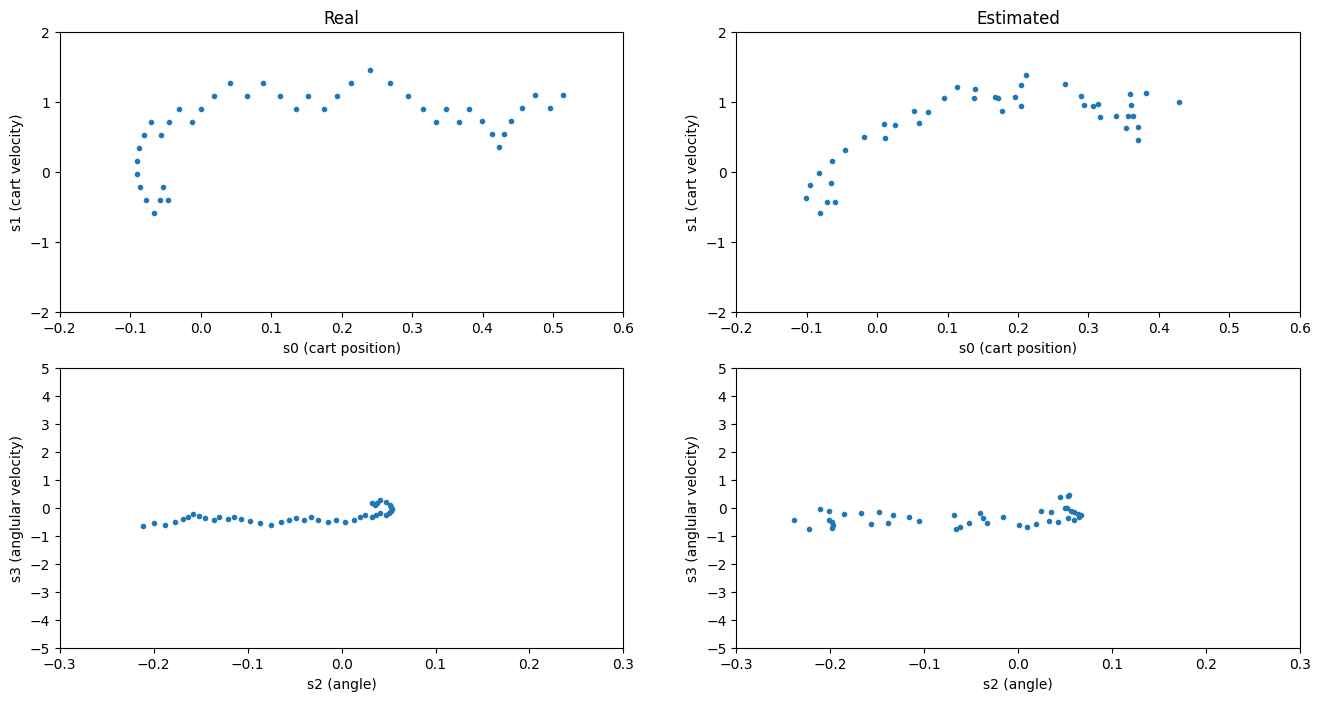

In [235]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8))

df = results.loc[results.episode == 3]

axs[0][0].scatter(x=df['s0'], y=df['s1'], marker='.')
axs[1][0].scatter(x=df['s2'], y=df['s3'], marker='.')

axs[0][1].scatter(x=df['estimated_s0'], y=df['estimated_s1'], marker='.')
axs[1][1].scatter(x=df['estimated_s2'], y=df['estimated_s3'], marker='.')

axs[0][0].set_title('Real')
axs[0][1].set_title('Estimated')

for i, _ in enumerate(axs[0]):
    axs[0][i].set_ylabel('s1 (cart velocity)')
    axs[0][i].set_xlabel('s0 (cart position)')
    axs[0][i].set_yticks(range(-2,3))
    axs[0][i].set_xticks([i/10 for i in range(-2,7)])

for i, _ in enumerate(axs[0]):
    axs[1][i].set_ylabel('s3 (anglular velocity)')
    axs[1][i].set_xlabel('s2 (angle)')
    axs[1][i].set_yticks(range(-5,6))
    axs[1][i].set_xticks([i/10 for i in range(-3,4)])

plt.show()

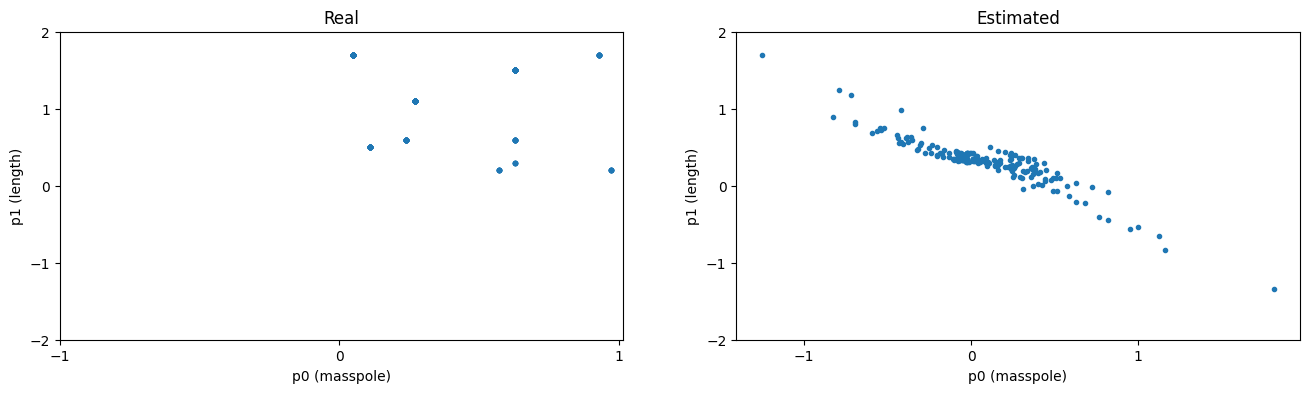

In [236]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

# df = results.loc[results.episode == 3]
df = results

axs[0].scatter(x=df['p0'], y=df['p1'], marker='.')
axs[1].scatter(x=df['estimated_p0'], y=df['estimated_p1'], marker='.')

axs[0].set_title('Real')
axs[1].set_title('Estimated')

for ax in axs:
    ax.set_ylabel('p1 (length)')
    ax.set_xlabel('p0 (masspole)')
    ax.set_yticks(range(-2,3))
    ax.set_xticks(range(-1,2))

plt.show()

In [239]:
from sklearn.cluster import KMeans
import numpy as np
X = df[['p0', 'p1']]
kmeans = KMeans(n_clusters=5, random_state=50, n_init="auto").fit(X)
kmeans.labels_
# kmeans.predict([[0, 0], [12, 3]])
# kmeans.cluster_centers_

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3], dtype=int32)

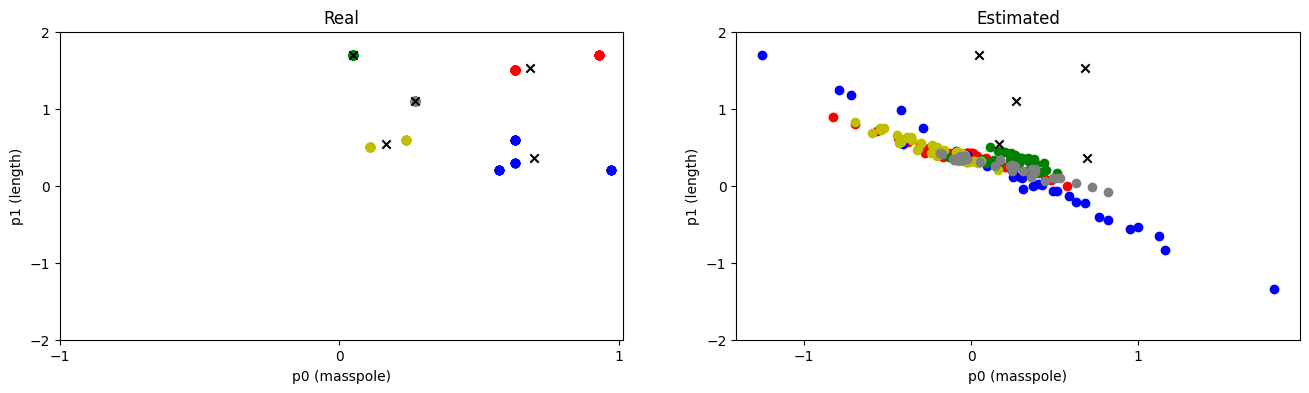

In [242]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

colors = ['r', 'b', 'g', 'y', 'gray']

for i, label in enumerate(np.unique(kmeans.labels_)):
    cluster_points = X[kmeans.labels_ == label]
    axs[0].scatter(cluster_points['p0'], cluster_points['p1'], color=colors[i])
axs[0].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color='black', marker='x')

for i, label in enumerate(np.unique(kmeans.labels_)):
    cluster_points = df[kmeans.labels_ == label]
    axs[1].scatter(cluster_points['estimated_p0'], cluster_points['estimated_p1'], color=colors[i])
axs[1].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color='black', marker='x')


axs[0].set_title('Real')
axs[1].set_title('Estimated')

for ax in axs:
    ax.set_ylabel('p1 (length)')
    ax.set_xlabel('p0 (masspole)')
    ax.set_yticks(range(-2,3))
    ax.set_xticks(range(-1,2))

plt.show()

# Evaluation

In [ ]:
data.evaluate_model(model, path='testing_data.csv')
results = data.get_evaluation_metrics()
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,...,estimated_s3,p0,p1,estimated_p0,estimated_p1,rse_s0,rse_s1,rse_s2,rse_s3,rse_r
0,0,0,"(0.27, 1.9)","(-0.037, 0.026, -0.021, 0.016)",0,1.0,"(-0.036, -0.159, -0.02, 0.102)",0.0,1.0,"(-0.04, -0.345, -0.018, 0.188)",...,0.354,0.27,1.9,0.370,0.565,0.009,0.056,0.054,0.166,0.7
1,1,0,"(0.27, 1.9)","(-0.036, -0.159, -0.02, 0.102)",0,1.0,"(-0.04, -0.345, -0.018, 0.188)",0.0,1.0,"(-0.047, -0.531, -0.014, 0.274)",...,0.405,0.27,1.9,0.364,0.635,0.010,0.037,0.048,0.131,0.8
2,2,0,"(0.27, 1.9)","(-0.04, -0.345, -0.018, 0.188)",0,1.0,"(-0.047, -0.531, -0.014, 0.274)",1.0,1.0,"(-0.057, -0.345, -0.009, 0.185)",...,-0.085,0.27,1.9,0.357,0.705,0.001,0.048,0.022,0.270,0.7
3,3,0,"(0.27, 1.9)","(-0.047, -0.531, -0.014, 0.274)",1,1.0,"(-0.057, -0.345, -0.009, 0.185)",0.0,1.0,"(-0.064, -0.531, -0.005, 0.272)",...,0.428,0.27,1.9,0.379,0.619,0.000,0.033,0.052,0.156,0.7
4,4,0,"(0.27, 1.9)","(-0.057, -0.345, -0.009, 0.185)",0,1.0,"(-0.064, -0.531, -0.005, 0.272)",1.0,1.0,"(-0.075, -0.345, 0.0, 0.183)",...,-0.078,0.27,1.9,0.354,0.698,0.010,0.045,0.019,0.261,0.7


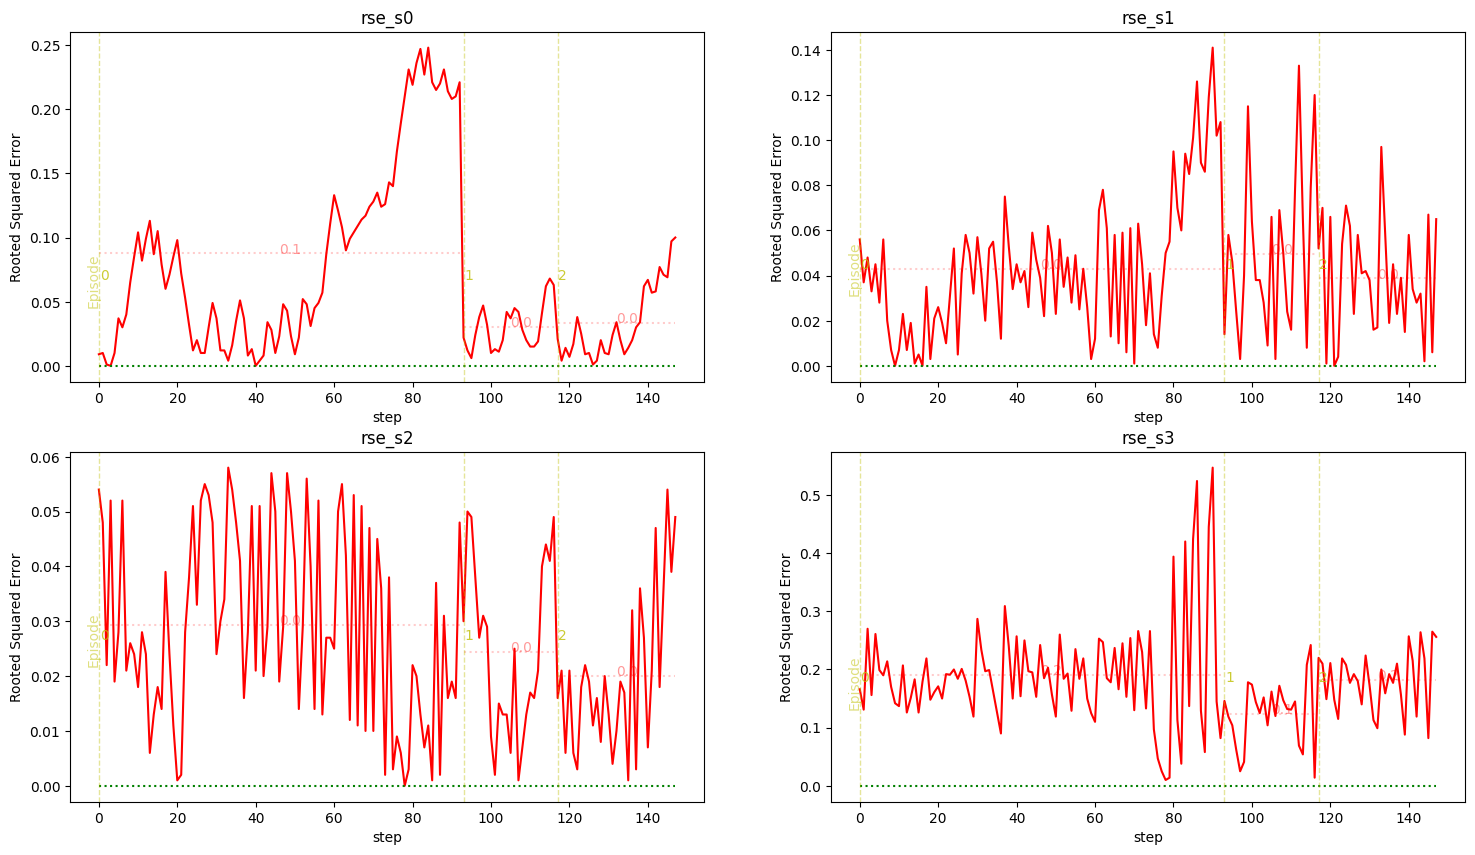

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

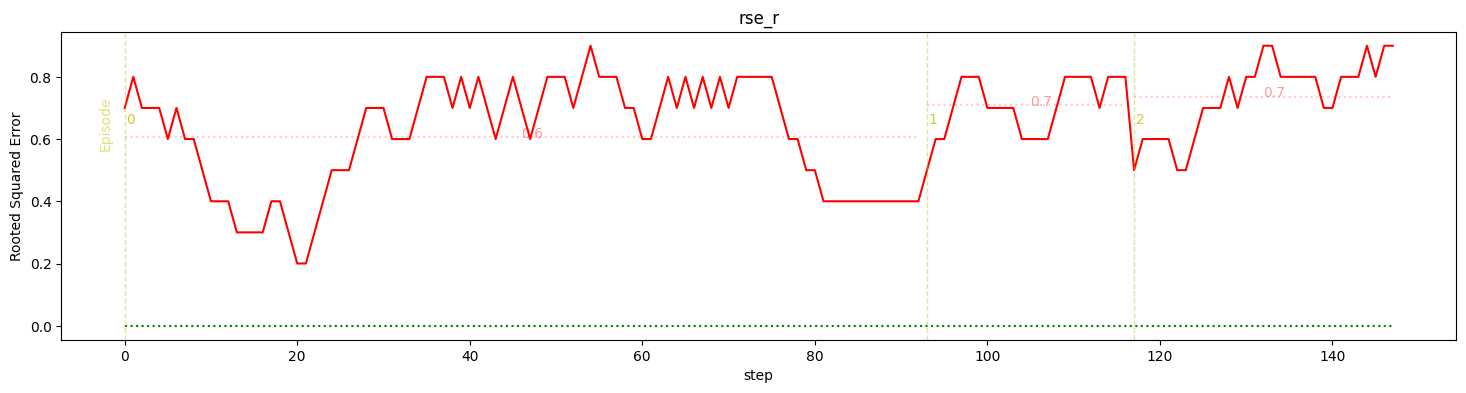

In [17]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

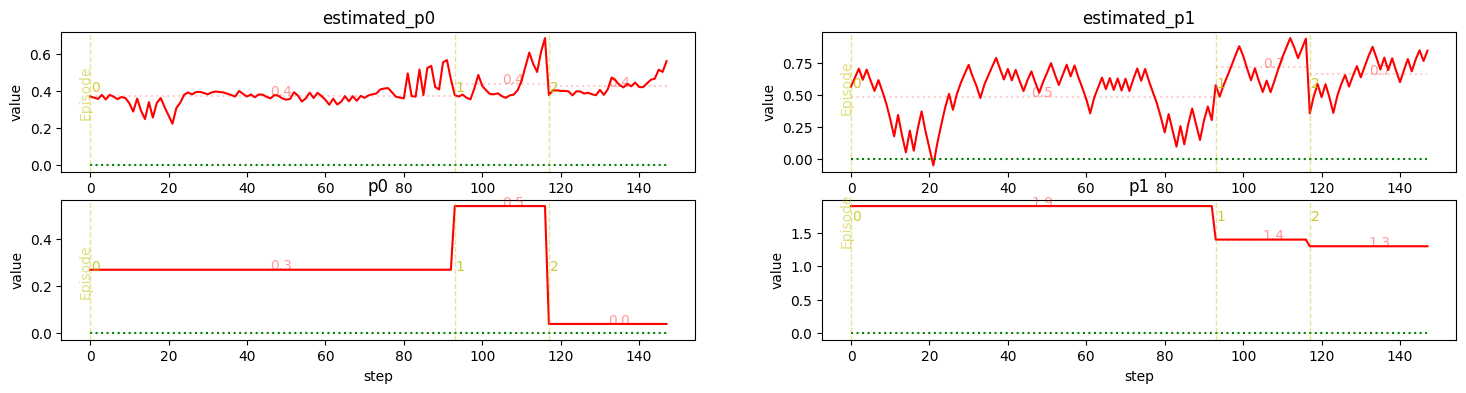

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(18,4))
data.plot_value_through_episodes(axs[0][0], results, 'estimated_p0', y_label='value')
data.plot_value_through_episodes(axs[0][1], results, 'estimated_p1', y_label='value')
data.plot_value_through_episodes(axs[1][0], results, 'p0', y_label='value')
data.plot_value_through_episodes(axs[1][1], results, 'p1', y_label='value')
plt.show()

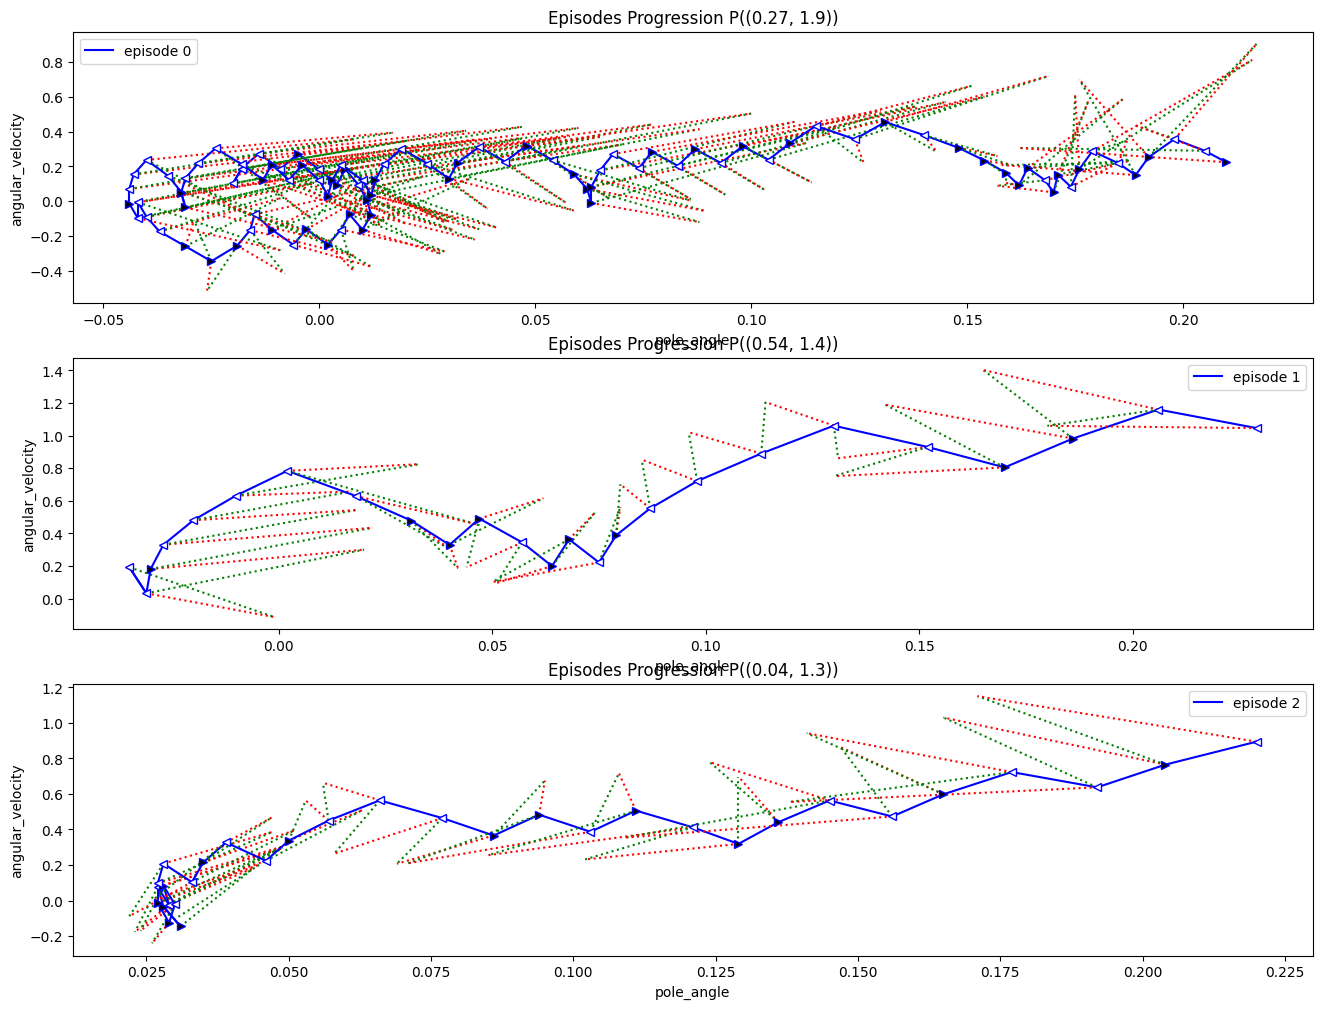

In [19]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()